In [1]:
import json
import math
import pickle
from collections import defaultdict
import pandas as pd
import numpy as np

import torch
import dgl
import json
import lda
from sklearn.feature_extraction.text import CountVectorizer


/home/qian/anaconda3/envs/csh_test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 读取JSON文件
with open('available_dataset.json', 'r', encoding='utf-8') as f:
  data = json.load(f)

In [5]:
# ------------------------
# 全局配置参数
# ------------------------
# 1. 输入、输出文件
INPUT_JSON = 'available_dataset.json'
OUTPUT_JSON = 'available_dataset_with_subtopic.json'

# 2. 全局参数 k，期望所有大话题下子话题总数大约为 k
k = 10000

# 3. 停用词（可自行替换/扩充）
stopwords = [
    '的','了','和','是','在','就','不','都','而','及','与','中','为','对','你','我','他'
]

# ------------------------
# 动态分配子话题数的函数
# ------------------------
def allocate_n_topics(num_docs, sum_docs, k, min_topics=1, max_topics=10):
    """
    根据文档占比和全局 k 分配 n_topics。
    如果文档数特别少，直接返回1（不做子话题划分）。
    """
    if num_docs < 5:
        # 太少，直接给 1
        return 1
    ratio = num_docs / float(sum_docs)    # 当前大话题文档量占总数的比例
    candidate = int(round(ratio * k))    # 根据占比为当前话题分配子话题数
    candidate = max(candidate, min_topics)
    candidate = min(candidate, max_topics)
    return candidate

# ------------------------
# 辅助函数：拼接文本
# ------------------------
def get_full_text(video_info):
    """
    将 desc + title + content 合并为一段文本。
    你可以根据需求自定义拼接逻辑或使用更高级的文本预处理。
    """
    desc = video_info.get('描述', '') or ''
    title = video_info.get('标题', '') or ''
    content = video_info.get('内容', '') or ''
    return f"{title} {desc} {content}".strip()

# ------------------------
# 1. 读取原始 JSON
# ------------------------
with open(INPUT_JSON, 'r', encoding='utf-8') as f:
    data = json.load(f)

# ------------------------
# 2. 按大话题分组
# ------------------------
topic_groups = {}
total_docs = 0  # 统计所有视频的总数

for video_key, video_info in data.items():
    topic = str(video_info.get('话题', '')).strip()
    if not topic:
        topic = "未知话题"
    if topic not in topic_groups:
        topic_groups[topic] = []
    topic_groups[topic].append((video_key, video_info))
    total_docs += 1
print(total_docs)
# ------------------------
# 3. 对每个大话题做 LDA
# ------------------------
subtopic_count_sum = 0  # 用来统计所有大话题下子话题数之和

for topic, video_list in topic_groups.items():
    num_docs = len(video_list)

    # (3.1) 计算本大话题的子话题数
    n_topics = allocate_n_topics(
        num_docs=num_docs,
        sum_docs=total_docs,
        k=k,
        min_topics=1,
        max_topics=100
    )

    # (3.2) 如果 n_topics == 1，说明无需细分，直接 subtopic=0
    if n_topics <= 1:
        for (video_key, _) in video_list:
            data[video_key]['子话题'] = 0
        subtopic_count_sum += 1  # 算作1个子话题（实际就是没分）
        continue

    # (3.3) 构建文档列表（desc+title+content）
    documents = []
    video_keys = []
    for (video_key, video_info) in video_list:
        documents.append(get_full_text(video_info))
        video_keys.append(video_key)

    # (3.4) 如果文档过少无法做LDA，subtopic=0
    if len(documents) < 2:
        for vk in video_keys:
            data[vk]['子话题'] = 0
        subtopic_count_sum += 1
        continue

    # (3.5) CountVectorizer
    vectorizer = CountVectorizer(min_df=3, stop_words=stopwords)
    tf = vectorizer.fit_transform(documents)

    # (3.6) LDA 训练
    model = lda.LDA(n_topics=n_topics, n_iter=150, random_state=1)
    model.fit(tf)

    # (3.7) doc_topic: 每篇文档对 n_topics 的概率分布
    doc_topic = model.doc_topic_
    for i, video_key in enumerate(video_keys):
        # 取概率最高的那个子话题下标
        subtopic_idx = int(np.argmax(doc_topic[i]))
        data[video_key]['子话题'] = subtopic_idx

    # (3.8) 累加子话题总数
    subtopic_count_sum += n_topics

# ------------------------
# 4. 输出统计结果
# ------------------------
print(f"所有大话题下的子话题总数约为: {subtopic_count_sum}")

# ------------------------
# 5. 写回新的 JSON 文件
# ------------------------
with open(OUTPUT_JSON, 'w', encoding='utf-8') as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

print(f"已完成 LDA 子话题划分，写入 {OUTPUT_JSON}。最终子话题总数: {subtopic_count_sum}")


INFO:lda:n_documents: 47
INFO:lda:vocab_size: 42
INFO:lda:n_words: 184
INFO:lda:n_topics: 5
INFO:lda:n_iter: 150
INFO:lda:<0> log likelihood: -1476
INFO:lda:<10> log likelihood: -794
INFO:lda:<20> log likelihood: -743
INFO:lda:<30> log likelihood: -719
INFO:lda:<40> log likelihood: -706
INFO:lda:<50> log likelihood: -717
INFO:lda:<60> log likelihood: -729
INFO:lda:<70> log likelihood: -706
INFO:lda:<80> log likelihood: -694
INFO:lda:<90> log likelihood: -691
INFO:lda:<100> log likelihood: -691
INFO:lda:<110> log likelihood: -691


96936


INFO:lda:<120> log likelihood: -701
INFO:lda:<130> log likelihood: -696
INFO:lda:<140> log likelihood: -700
INFO:lda:<149> log likelihood: -692
INFO:lda:n_documents: 76
INFO:lda:vocab_size: 88
INFO:lda:n_words: 777
INFO:lda:n_topics: 8
INFO:lda:n_iter: 150
INFO:lda:<0> log likelihood: -6495
INFO:lda:<10> log likelihood: -3334
INFO:lda:<20> log likelihood: -3233
INFO:lda:<30> log likelihood: -3193
INFO:lda:<40> log likelihood: -3144
INFO:lda:<50> log likelihood: -3104
INFO:lda:<60> log likelihood: -3061
INFO:lda:<70> log likelihood: -3082
INFO:lda:<80> log likelihood: -3065
INFO:lda:<90> log likelihood: -3038
INFO:lda:<100> log likelihood: -3043
INFO:lda:<110> log likelihood: -3021
INFO:lda:<120> log likelihood: -3060
INFO:lda:<130> log likelihood: -3028
INFO:lda:<140> log likelihood: -2961
INFO:lda:<149> log likelihood: -2944
INFO:lda:n_documents: 17
INFO:lda:vocab_size: 7
INFO:lda:n_words: 36
INFO:lda:n_topics: 2
INFO:lda:n_iter: 150
INFO:lda:<0> log likelihood: -163
INFO:lda:<10> log

所有大话题下的子话题总数约为: 7807
已完成 LDA 子话题划分，写入 available_dataset_with_subtopic.json。最终子话题总数: 7807


In [6]:
# 读取JSON文件
with open('available_dataset_with_subtopic.json', 'r', encoding='utf-8') as f:
  data = json.load(f)

In [5]:
pf_set = set()
for k in data:
    pf_set.add(data[k]['平台'])
pf_set

{'哔哩哔哩', '头条', '快手', '抖音', '西瓜'}

In [1]:
import dgl
dgl.load_graphs('heterogeneous_graph.pkl')

/home/qian/anaconda3/envs/csh_test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


([Graph(num_nodes={'comment': 16939, 'content': 7170, 'desc': 86599, 'fans': 58539, 'subtopic': 7701, 'title': 70147, 'topic': 471, 'user': 58539, 'video': 96936},
        num_edges={('comment', 'comment_of', 'video'): 27153, ('content', 'content_of', 'video'): 9335, ('desc', 'desc_of', 'video'): 96936, ('fans', 'fans_of', 'user'): 58539, ('subtopic', 'belongs_to', 'topic'): 96936, ('subtopic', 'subtopic_of', 'video'): 96936, ('title', 'title_of', 'video'): 85674, ('topic', 'has_subtopic', 'subtopic'): 96936, ('user', 'has_fans', 'fans'): 58539, ('user', 'published', 'video'): 96885, ('video', 'has_comment', 'comment'): 27153, ('video', 'has_content', 'content'): 9335, ('video', 'has_desc', 'desc'): 96936, ('video', 'has_subtopic', 'subtopic'): 96936, ('video', 'has_title', 'title'): 85674, ('video', 'published_by', 'user'): 96885},
        metagraph=[('comment', 'video', 'comment_of'), ('video', 'comment', 'has_comment'), ('video', 'content', 'has_content'), ('video', 'desc', 'has_des

In [15]:
# ============== 配置区 ==============
INPUT_JSON = 'available_dataset_with_subtopic.json'
OUTPUT_GRAPH = 'heterogeneous_graph.pkl'
NODE_MAPPING_JSON = 'node_id_mapping.json'

# CSV 文件输出
TOPIC_LABEL_CSV = 'topic_label.csv'
SUBTOPIC_LABEL_CSV = 'subtopic_label.csv'
VIDEO_LABEL_CSV = 'video_label.csv'

# 节点信息输出
VIDEO_CSV = 'video.csv'
TOPIC_CSV = 'topic.csv'
SUBTOPIC_CSV = 'subtopic.csv'
DESC_CSV = 'desc.csv'
TITLE_CSV = 'title.csv'
CONTENT_CSV = 'content.csv'
COMMENT_CSV = 'comment.csv'
USER_CSV = 'user.csv'
FANS_CSV = 'fans.csv'

# ============== 1. 定义节点类型、边类型 ==============
node_types = [
    'video', 'desc', 'title', 'content', 'topic', 
    'subtopic',  # 新增子话题节点类型
    'comment', 'user', 'fans'
]

# 为每种节点类型建立 ID 映射
node_id_mapping = {ntype: {} for ntype in node_types}
current_id = {ntype: 0 for ntype in node_types}

# 双向边类型定义：从 video->subtopic->topic 的路径替代原有 video->topic
edge_types = [
    # video <-> desc
    ('video', 'has_desc', 'desc'),
    ('desc', 'desc_of', 'video'),
    # video <-> title
    ('video', 'has_title', 'title'),
    ('title', 'title_of', 'video'),
    # video <-> content
    ('video', 'has_content', 'content'),
    ('content', 'content_of', 'video'),
    # video <-> subtopic
    ('video', 'has_subtopic', 'subtopic'),
    ('subtopic', 'subtopic_of', 'video'),
    # subtopic <-> topic
    ('subtopic', 'belongs_to', 'topic'),
    ('topic', 'has_subtopic', 'subtopic'),
    # video <-> comment
    ('video', 'has_comment', 'comment'),
    ('comment', 'comment_of', 'video'),
    # video <-> user
    ('video', 'published_by', 'user'),
    ('user', 'published', 'video'),
    # user <-> fans
    ('user', 'has_fans', 'fans'),
    ('fans', 'fans_of', 'user')
]
edges_dict = {etype: ([], []) for etype in edge_types}

# 节点特征
node_features = {ntype: {} for ntype in node_types}

# ============== 2. 用于累加统计的字典 ==============
topic_dict = defaultdict(lambda: {'view': 0, 'comment': 0, 'share': 0})
subtopic_dict = defaultdict(lambda: {'view': 0, 'comment': 0, 'share': 0})
video_dict = defaultdict(lambda: {'view': 0, 'comment': 0, 'share': 0})

# 用户最大粉丝数
user_fans = defaultdict(int)

# ============== 3. 辅助函数 ==============
def get_or_create_node_id(ntype, identifier):
    """给指定节点类型 ntype 的 identifier 分配一个唯一ID。"""
    if identifier not in node_id_mapping[ntype]:
        node_id_mapping[ntype][identifier] = current_id[ntype]
        current_id[ntype] += 1
    return node_id_mapping[ntype][identifier]

# ============== 4. 读取 JSON 并构建图数据 ==============
with open(INPUT_JSON, 'r', encoding='utf-8') as f:
    data = json.load(f)

for video_key, video_value in data.items():
    # 4.1 创建/获取 video 节点 ID
    video_id = get_or_create_node_id('video', video_key)

    # 计算 video 的 max(view/comment/share)
    time_frames = video_value.get('互动量信息', {})
    max_view, max_comment, max_share, max_fans = 0, 0, 0, 0
    for date, counts in time_frames.items():
        v = counts.get('播放量') or 0
        c = counts.get('评论量') or 0
        s = counts.get('分享量') or 0
        f_ = counts.get('粉丝量') or 0
        if v > max_view:       max_view = v
        if c > max_comment:    max_comment = c
        if s > max_share:      max_share = s
        if f_ > max_fans:      max_fans = f_

    # 保存 video 节点信息
    node_features['video'][video_id] = {
        'url': video_value.get('url', ''),
        'key': video_key
    }
    video_dict[video_id]['view']    = max_view
    video_dict[video_id]['comment'] = max_comment
    video_dict[video_id]['share']   = max_share

    # 4.2 desc/title/content
    desc = (video_value.get('描述') or '').strip()
    if desc:
        desc_id = get_or_create_node_id('desc', desc)
        node_features['desc'][desc_id] = {'text': desc, 'feat': len(desc)}
        edges_dict[('video', 'has_desc', 'desc')][0].append(video_id)
        edges_dict[('video', 'has_desc', 'desc')][1].append(desc_id)
        edges_dict[('desc', 'desc_of', 'video')][0].append(desc_id)
        edges_dict[('desc', 'desc_of', 'video')][1].append(video_id)

    title = (video_value.get('标题') or '').strip()
    if title:
        title_id = get_or_create_node_id('title', title)
        node_features['title'][title_id] = {'text': title, 'feat': len(title)}
        edges_dict[('video', 'has_title', 'title')][0].append(video_id)
        edges_dict[('video', 'has_title', 'title')][1].append(title_id)
        edges_dict[('title', 'title_of', 'video')][0].append(title_id)
        edges_dict[('title', 'title_of', 'video')][1].append(video_id)

    content = (video_value.get('内容') or '').strip()
    if content:
        content_id = get_or_create_node_id('content', content)
        node_features['content'][content_id] = {'text': content, 'feat': len(content)}
        edges_dict[('video', 'has_content', 'content')][0].append(video_id)
        edges_dict[('video', 'has_content', 'content')][1].append(content_id)
        edges_dict[('content', 'content_of', 'video')][0].append(content_id)
        edges_dict[('content', 'content_of', 'video')][1].append(content_id)

    # 4.3 大话题 topic
    topic_str = (video_value.get('话题') or '').strip()
    if not topic_str:
        topic_str = "未知话题"
    topic_id = get_or_create_node_id('topic', topic_str)

    # 4.4 子话题 subtopic
    subtopic_num = video_value.get('子话题') or 0
    subtopic_identifier = f"{topic_str}_{subtopic_num}"
    subtopic_id = get_or_create_node_id('subtopic', subtopic_identifier)
    node_features['subtopic'][subtopic_id] = {'text': subtopic_identifier}

    # 连接 video <-> subtopic
    edges_dict[('video', 'has_subtopic', 'subtopic')][0].append(video_id)
    edges_dict[('video', 'has_subtopic', 'subtopic')][1].append(subtopic_id)
    edges_dict[('subtopic', 'subtopic_of', 'video')][0].append(subtopic_id)
    edges_dict[('subtopic', 'subtopic_of', 'video')][1].append(video_id)

    # 连接 subtopic <-> topic
    edges_dict[('subtopic', 'belongs_to', 'topic')][0].append(subtopic_id)
    edges_dict[('subtopic', 'belongs_to', 'topic')][1].append(topic_id)
    edges_dict[('topic', 'has_subtopic', 'subtopic')][0].append(topic_id)
    edges_dict[('topic', 'has_subtopic', 'subtopic')][1].append(subtopic_id)

    # 累加到 subtopic_dict & topic_dict
    subtopic_dict[subtopic_identifier]['view']    += max_view
    subtopic_dict[subtopic_identifier]['comment'] += max_comment
    subtopic_dict[subtopic_identifier]['share']   += max_share

    topic_dict[topic_str]['view']    += max_view
    topic_dict[topic_str]['comment'] += max_comment
    topic_dict[topic_str]['share']   += max_share

    # 4.5 评论comment（最多5条）
    comments = video_value.get('评论', {})
    c_count = 0
    for ckey, cval in comments.items():
        if c_count >= 5:
            break
        comtext = (cval.get('评论内容') or '').strip()
        if comtext:
            com_id = get_or_create_node_id('comment', comtext)
            node_features['comment'][com_id] = {'text': comtext, 'feat': len(comtext)}
            edges_dict[('video', 'has_comment', 'comment')][0].append(video_id)
            edges_dict[('video', 'has_comment', 'comment')][1].append(com_id)
            edges_dict[('comment', 'comment_of', 'video')][0].append(com_id)
            edges_dict[('comment', 'comment_of', 'video')][1].append(video_id)
            c_count += 1

    # 4.6 user
    user_id_str = (video_value.get('发布用户ID') or '').strip()
    if user_id_str:
        user_id = get_or_create_node_id('user', user_id_str)
        node_features['user'][user_id] = {'user_id': user_id_str}
        edges_dict[('video', 'published_by', 'user')][0].append(video_id)
        edges_dict[('video', 'published_by', 'user')][1].append(user_id)
        edges_dict[('user', 'published', 'video')][0].append(user_id)
        edges_dict[('user', 'published', 'video')][1].append(video_id)

        # 更新用户粉丝
        for date, cdict in time_frames.items():
            fans_val = cdict.get('fans_count') or 0
            if fans_val > user_fans[user_id]:
                user_fans[user_id] = fans_val

# ============== 5. 创建 fans 节点并建立边 ==============
for user_id, fans_count in user_fans.items():
    fans_identifier = f"fans_{user_id}"
    fans_nid = get_or_create_node_id('fans', fans_identifier)
    node_features['fans'][fans_nid] = {'feat': fans_count}
    edges_dict[('user', 'has_fans', 'fans')][0].append(user_id)
    edges_dict[('user', 'has_fans', 'fans')][1].append(fans_nid)
    edges_dict[('fans', 'fans_of', 'user')][0].append(fans_nid)
    edges_dict[('fans', 'fans_of', 'user')][1].append(user_id)

# ============== 6. 准备 DGL 图数据 ==============
graph_data = {}
for etype, (src_list, dst_list) in edges_dict.items():
    graph_data[etype] = (
        torch.tensor(src_list, dtype=torch.int32),
        torch.tensor(dst_list, dtype=torch.int32)
    )

num_nodes_dict = {ntype: len(node_id_mapping[ntype]) for ntype in node_types}
hg = dgl.heterograph(graph_data, num_nodes_dict=num_nodes_dict)

# ============== 7. 添加节点特征 ==============
import torch.nn as nn

for ntype in node_types:
    if ntype == 'topic':
        # 大话题节点不存储特征
        emb = nn.Parameter(torch.Tensor(hg.num_nodes(ntype), 400), requires_grad = False)
        nn.init.xavier_uniform_(emb)
        hg.nodes[ntype].data['feat'] = torch.tensor(emb).to(torch.float32)
    elif ntype == 'subtopic':
        # 简单示例：用文本长度当特征
        emb = nn.Parameter(torch.Tensor(hg.num_nodes(ntype), 400), requires_grad = False)
        nn.init.xavier_uniform_(emb)
        hg.nodes[ntype].data['feat'] = torch.tensor(emb).to(torch.float32)
    elif ntype == 'video':
        # 视频节点
        emb = nn.Parameter(torch.Tensor(hg.num_nodes(ntype), 400), requires_grad = False)
        nn.init.xavier_uniform_(emb)
        hg.nodes[ntype].data['feat'] = torch.tensor(emb).to(torch.float32)
    elif ntype in ['desc', 'title', 'content', 'comment']:
        emb = nn.Parameter(torch.Tensor(hg.num_nodes(ntype), 400), requires_grad = False)
        nn.init.xavier_uniform_(emb)
        hg.nodes[ntype].data['feat'] = torch.tensor(emb).to(torch.float32)
    elif ntype == 'user':
        emb = nn.Parameter(torch.Tensor(hg.num_nodes(ntype), 400), requires_grad = False)
        nn.init.xavier_uniform_(emb)
        hg.nodes[ntype].data['feat'] = torch.tensor(emb).to(torch.float32)
    elif ntype == 'fans':
        # 粉丝数
        feats = []
        for fid in range(num_nodes_dict['fans']):
            feats.append(node_features['fans'][fid]['feat'])
        hg.nodes['fans'].data['feat'] = torch.tensor(feats, dtype=torch.float32).unsqueeze(1)

# ============== 8. 生成标签数据并保存 CSV ==============
# 8.1 topic_label
topic_labels = []
for topic_str, tid in node_id_mapping['topic'].items():
    v = topic_dict[topic_str]['view']
    c = topic_dict[topic_str]['comment']
    s = topic_dict[topic_str]['share']
    v_log = math.log10(v + 1) if v > 0 else 0
    c_log = math.log10(c + 1) if c > 0 else 0
    s_log = math.log10(s + 1) if s > 0 else 0
    topic_labels.append({'id': tid, 'view': v_log, 'comment': c_log, 'share': s_log})
pd.DataFrame(topic_labels).to_csv(TOPIC_LABEL_CSV, index=False, encoding='utf-8')

# 8.2 subtopic_label
subtopic_labels = []
for subtopic_str, sid in node_id_mapping['subtopic'].items():
    v = subtopic_dict[subtopic_str]['view']
    c = subtopic_dict[subtopic_str]['comment']
    s = subtopic_dict[subtopic_str]['share']
    v_log = math.log10(v + 1) if v > 0 else 0
    c_log = math.log10(c + 1) if c > 0 else 0
    s_log = math.log10(s + 1) if s > 0 else 0
    subtopic_labels.append({'id': sid, 'view': v_log, 'comment': c_log, 'share': s_log})
pd.DataFrame(subtopic_labels).to_csv(SUBTOPIC_LABEL_CSV, index=False, encoding='utf-8')

# 8.3 video_label
video_labels = []
for vid in range(num_nodes_dict['video']):
    v = video_dict[vid]['view']
    c = video_dict[vid]['comment']
    s = video_dict[vid]['share']
    v_log = math.log10(v + 1) if v > 0 else 0
    c_log = math.log10(c + 1) if c > 0 else 0
    s_log = math.log10(s + 1) if s > 0 else 0
    video_labels.append({'id': vid, 'view': v_log, 'comment': c_log, 'share': s_log})
pd.DataFrame(video_labels).to_csv(VIDEO_LABEL_CSV, index=False, encoding='utf-8')

# ============== 9. 保存节点信息到 CSV ==============
# 9.1 video.csv
video_data = []
for vid in range(num_nodes_dict['video']):
    video_data.append({
        'id': vid,
        'url': node_features['video'][vid]['url'],
        'key': node_features['video'][vid]['key']
    })
pd.DataFrame(video_data).to_csv(VIDEO_CSV, index=False, encoding='utf-8')

# 9.2 subtopic.csv
subtopic_data = []
for subtopic_str, sid in node_id_mapping['subtopic'].items():
    subtopic_data.append({'id': sid, 'text': subtopic_str})
pd.DataFrame(subtopic_data).to_csv(SUBTOPIC_CSV, index=False, encoding='utf-8')

# 9.3 topic.csv
topic_data = []
for topic_str, tid in node_id_mapping['topic'].items():
    topic_data.append({'id': tid, 'text': topic_str})
pd.DataFrame(topic_data).to_csv(TOPIC_CSV, index=False, encoding='utf-8')

# 9.4 desc.csv, title.csv, content.csv, comment.csv
for ntype in ['desc', 'title', 'content', 'comment']:
    rows = []
    for nid in range(num_nodes_dict[ntype]):
        rows.append({'id': nid, 'text': node_features[ntype][nid]['text']})
    pd.DataFrame(rows).to_csv(f'{ntype}.csv', index=False, encoding='utf-8')

# 9.5 user.csv
user_data = []
for uid in range(num_nodes_dict['user']):
    user_data.append({
        'id': uid,
        'user_id': node_features['user'][uid]['user_id']
    })
pd.DataFrame(user_data).to_csv(USER_CSV, index=False, encoding='utf-8')

# 9.6 fans.csv
fans_data = []
for fid in range(num_nodes_dict['fans']):
    fans_data.append({
        'id': fid,
        'feat': node_features['fans'][fid]['feat']
    })
pd.DataFrame(fans_data).to_csv(FANS_CSV, index=False, encoding='utf-8')

# ============== 10. 保存异构图和节点映射 ==============
dgl.save_graphs(OUTPUT_GRAPH, [hg])

serializable_mapping = {}
for ntype, mapping in node_id_mapping.items():
    serializable_mapping[ntype] = {}
    for identifier, nid in mapping.items():
        serializable_mapping[ntype][identifier] = nid

with open(NODE_MAPPING_JSON, 'w', encoding='utf-8') as f:
    json.dump(serializable_mapping, f, ensure_ascii=False, indent=2)

print("===== 运行完毕 =====")
print(f"已构建三层结构的异构图(video -> subtopic -> topic)，并保存为: {OUTPUT_GRAPH}")
print(f"节点ID映射保存至: {NODE_MAPPING_JSON}")
print(f"子话题数值保存至: {SUBTOPIC_LABEL_CSV}")
print("其余节点/标签 CSV 文件也已写入。")


/tmp/ipykernel_2471895/1030229322.py:243: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hg.nodes[ntype].data['feat'] = torch.tensor(emb).to(torch.float32)
/tmp/ipykernel_2471895/1030229322.py:247: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hg.nodes[ntype].data['feat'] = torch.tensor(emb).to(torch.float32)
/tmp/ipykernel_2471895/1030229322.py:233: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hg.nodes[ntype].data['feat'] = torch.tensor(emb).to(torch.float32)
/tmp/ipykernel_2471895/1030229322.py:238: UserWarning: To copy construct from a

===== 运行完毕 =====
已构建三层结构的异构图(video -> subtopic -> topic)，并保存为: heterogeneous_graph.pkl
节点ID映射保存至: node_id_mapping.json
子话题数值保存至: subtopic_label.csv
其余节点/标签 CSV 文件也已写入。


In [1]:
import json
import dgl
import torch
import os
import pandas as pd

# 创建文件夹
os.makedirs('view_graph', exist_ok=True)
os.makedirs('comment_graph', exist_ok=True)
os.makedirs('share_graph', exist_ok=True)

# 读取数据
def read_data(file_path='available_dataset_with_subtopic.json'):
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)

# 获取或创建节点ID
def get_or_create_node_id(node_type, identifier, node_id_mapping):
    if identifier not in node_id_mapping[node_type]:
        node_id_mapping[node_type][identifier] = len(node_id_mapping[node_type])
    return node_id_mapping[node_type][identifier]

# 保存节点和边信息到 CSV
def save_to_csv(node_id_mapping, edges_dict, label, output_folder):
    # 节点数据存储
    node_data = []
    for node_type in node_id_mapping:
        for identifier, node_id in node_id_mapping[node_type].items():
            node_data.append({
                'node_type': node_type,
                'node_id': node_id,
                'identifier': identifier,
                'data_id': node_id,  # 为每个节点添加 data_id
            })

    # 将节点数据保存为 CSV
    node_df = pd.DataFrame(node_data)
    node_df.to_csv(os.path.join(output_folder, f'{label}_nodes.csv'), index=False)

    # 边数据存储
    edge_data = []
    for edge_type, (src_nodes, dst_nodes) in edges_dict.items():
        for src, dst in zip(src_nodes, dst_nodes):
            edge_data.append({
                'src_node': src,
                'dst_node': dst,
                'edge_type': edge_type[1],
                'src_node_type': edge_type[0],
                'dst_node_type': edge_type[2],
            })

    # 将边数据保存为 CSV
    edge_df = pd.DataFrame(edge_data)
    edge_df.to_csv(os.path.join(output_folder, f'{label}_edges.csv'), index=False)

# 生成图和保存 CSV
def generate_graph(label='view', file_path='available_dataset_with_subtopic.json'):
    data = read_data(file_path)

    # 初始化数据结构
    node_id_mapping = {'video': {}, 'topic': {}, 'subtopic': {}, 'desc': {}, 'title': {}, 'content': {}, 'user': {}, 'fans': {}}
    edges_dict = {('video', 'has_topic', 'topic'): ([], []),
                  ('topic', 'is_topic_of', 'video'): ([], []),
                  ('video', 'has_subtopic', 'subtopic'): ([], []),
                  ('subtopic', 'is_subtopic_of', 'video'): ([], []),
                  ('video', 'has_description', 'desc'): ([], []),
                  ('desc', 'is_description_of', 'video'): ([], []),
                  ('video', 'has_title', 'title'): ([], []),
                  ('title', 'is_title_of', 'video'): ([], []),
                  ('video', 'has_content', 'content'): ([], []),
                  ('content', 'is_content_of', 'video'): ([], []),
                  ('video', 'published_by', 'user'): ([], []),
                  ('user', 'published', 'video'): ([], []),
                  ('user', 'has_fans', 'fans'): ([], []),
                  ('fans', 'fans_of', 'user'): ([], []),
                  ('video', 'viewed_on', 'platform'): ([], [])}

    node_features = {'video': {}, 'topic': {}, 'subtopic': {}, 'desc': {}, 'title': {}, 'content': {}, 'user': {}, 'fans': {}}
    video_dict = {}

    for video_key, video_value in data.items():
        # 读取视频数据
        video_id = get_or_create_node_id('video', video_key, node_id_mapping)
        node_features['video'][video_id] = {
            'video_id': video_key,
            'views': video_value['播放量'],
            'comments': video_value['评论量'],
            'shares': video_value['分享量'],
            'likes': video_value['点赞量'],
            'platform': video_value.get('平台', '')
        }
        
        video_dict[video_key] = {
            'view': video_value['播放量'],
            'comment': video_value['评论量'],
            'share': video_value['分享量']
        }

        # 跳过平台为抖音的视频
        if video_value.get('平台') == '抖音':
            continue

        # 处理话题和子话题
        topic_str = video_value.get('话题', '')
        subtopic_identifier = video_value.get('子话题', '')

        topic_id = get_or_create_node_id('topic', topic_str, node_id_mapping)
        subtopic_id = get_or_create_node_id('subtopic', subtopic_identifier, node_id_mapping)

        # 添加话题和子话题到视频节点之间的关系
        edges_dict[('video', 'has_topic', 'topic')][0].append(video_id)
        edges_dict[('video', 'has_topic', 'topic')][1].append(topic_id)
        edges_dict[('topic', 'is_topic_of', 'video')][0].append(topic_id)
        edges_dict[('topic', 'is_topic_of', 'video')][1].append(video_id)

        edges_dict[('video', 'has_subtopic', 'subtopic')][0].append(video_id)
        edges_dict[('video', 'has_subtopic', 'subtopic')][1].append(subtopic_id)
        edges_dict[('subtopic', 'is_subtopic_of', 'video')][0].append(subtopic_id)
        edges_dict[('subtopic', 'is_subtopic_of', 'video')][1].append(video_id)

    # 选择合适的label生成对应的图
    if label == 'view':
        graph_label = 'views'
        output_folder = 'view_graph'
    elif label == 'comment':
        graph_label = 'comments'
        output_folder = 'comment_graph'
    elif label == 'share':
        graph_label = 'shares'
        output_folder = 'share_graph'
    else:
        raise ValueError("Invalid label. Choose 'view', 'comment' or 'share'.")

    # 创建图
    graph = dgl.heterograph({
        ('video', 'has_topic', 'topic'): (edges_dict[('video', 'has_topic', 'topic')][0], edges_dict[('video', 'has_topic', 'topic')][1]),
        ('topic', 'is_topic_of', 'video'): (edges_dict[('topic', 'is_topic_of', 'video')][0], edges_dict[('topic', 'is_topic_of', 'video')][1]),
        ('video', 'has_subtopic', 'subtopic'): (edges_dict[('video', 'has_subtopic', 'subtopic')][0], edges_dict[('video', 'has_subtopic', 'subtopic')][1]),
        ('subtopic', 'is_subtopic_of', 'video'): (edges_dict[('subtopic', 'is_subtopic_of', 'video')][0], edges_dict[('subtopic', 'is_subtopic_of', 'video')][1])
    })

    # 保存到文件夹
    output_file = os.path.join(output_folder, f'{label}_graph.bin')
    torch.save(graph, output_file)

    # 保存节点和边信息到CSV
    save_to_csv(node_id_mapping, edges_dict, label, output_folder)

    print(f"{label.capitalize()} graph and CSV files have been saved in '{output_folder}' folder.")

# ============== 运行函数生成图并保存 CSV ==============
generate_graph(label='view')    # 生成 'view' 图并保存
generate_graph(label='comment') # 生成 'comment' 图并保存
generate_graph(label='share')   # 生成 'share' 图并保存


/home/qian/anaconda3/envs/csh_test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyError: '播放量'

/home/qian/anaconda3/envs/csh_test/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/qian/anaconda3/envs/csh_test/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/qian/anaconda3/envs/csh_test/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/qian/anaconda3/envs/csh_test/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/qian/anaconda3/envs/csh_test/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will b

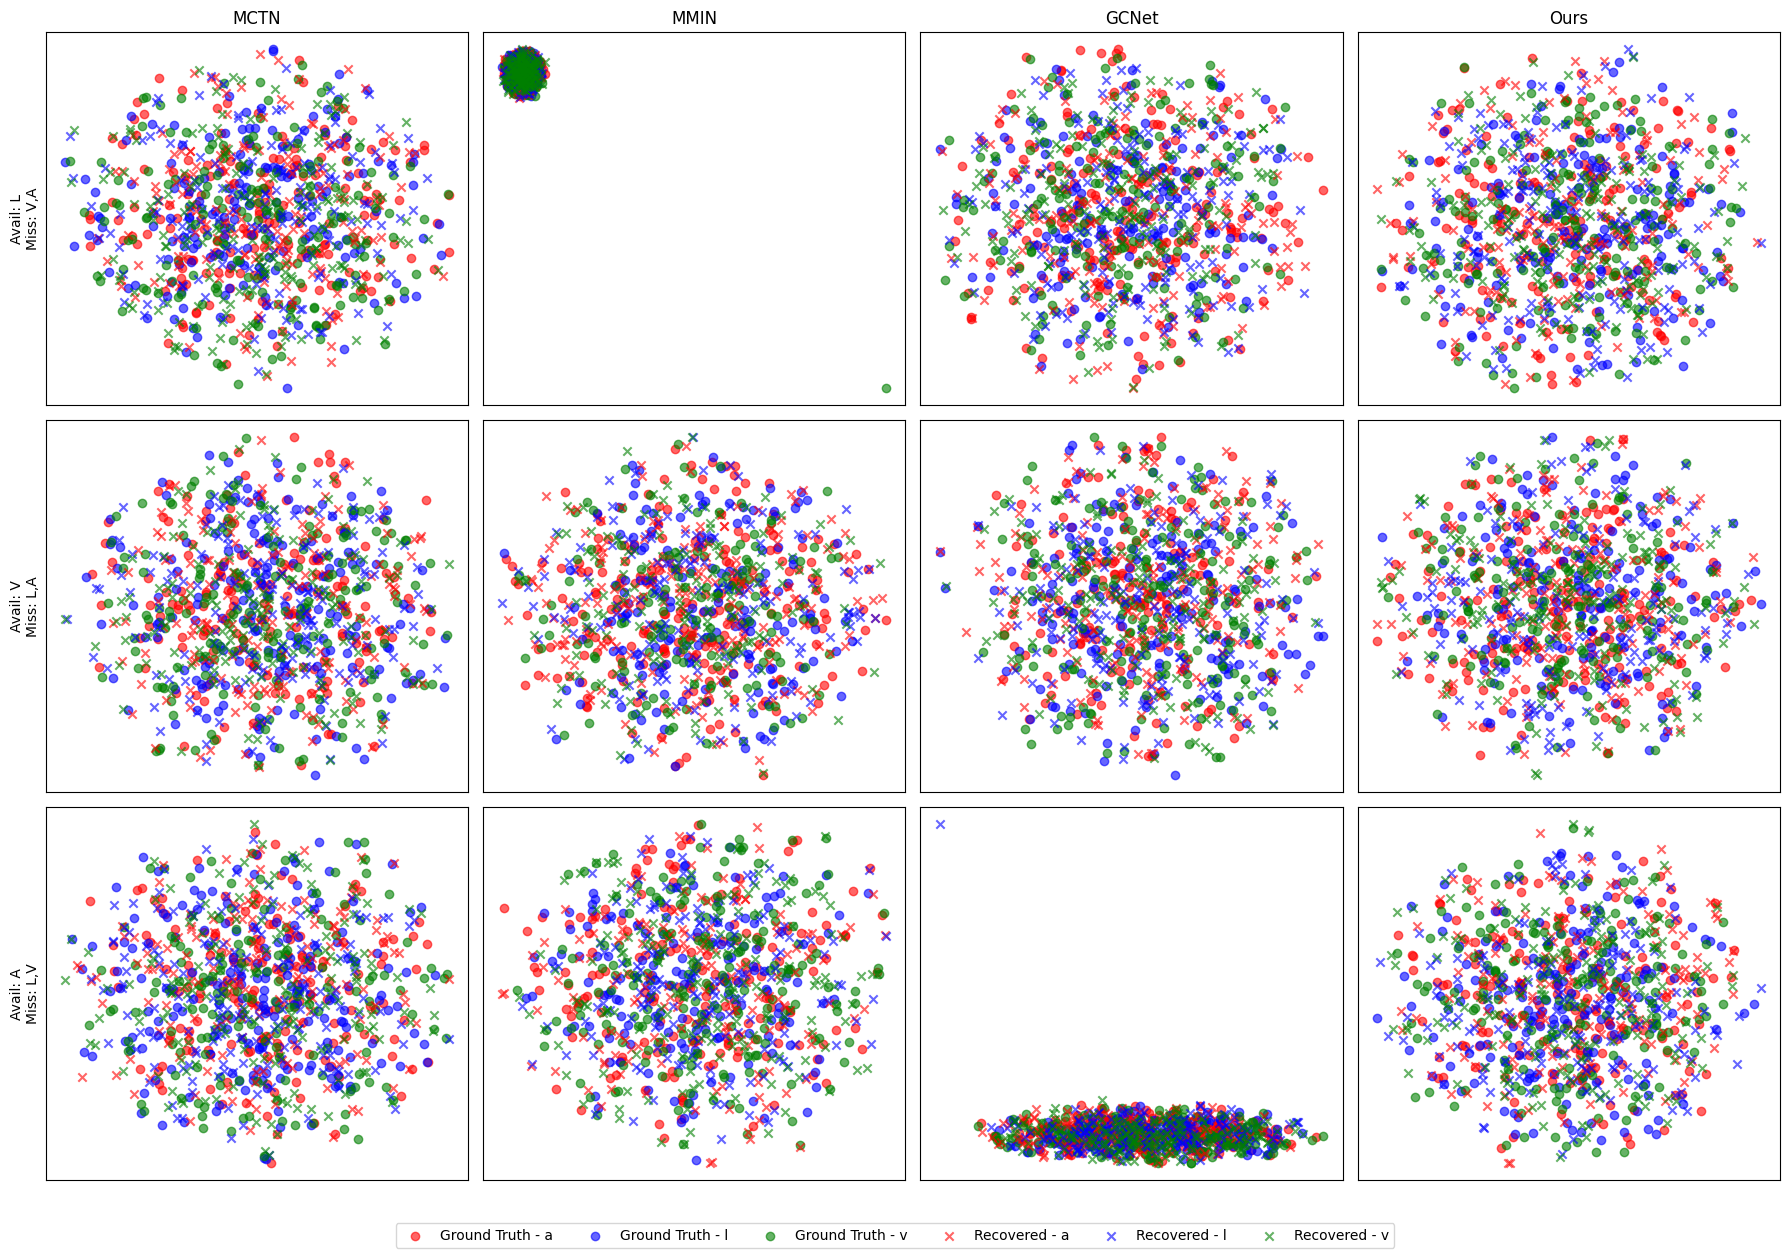

In [29]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import random

# Step 1: Random data generation function (with reduced data points for speed)
def generate_random_data():
    """
    Generate random data for 500 samples and 768 features, where each sample 
    has a label (l, v, or a) randomly assigned to it.
    """
    data = np.random.rand(500, 768)  # 00 samples, 768 features (reduced for speed)
    labels = np.array([random.choice(['l', 'v', 'a']) for _ in range(500)])  # Random labels for each sample
    return data, labels

# Step 2: Apply t-SNE for dimensionality reduction with PCA initialization for faster convergence
def apply_tsne(ground_truth_data, recovered_data):
    """
    Apply t-SNE on the concatenated data to reduce it to 2D with PCA initialization.
    """
    # Combine ground truth and recovered data into a single dataset
    combined_data = np.vstack([ground_truth_data, recovered_data])
    
    tsne = TSNE(n_components=2, random_state=42, init='pca', n_iter=300)  # Added PCA init and fewer iterations
    reduced_data = tsne.fit_transform(combined_data)
    
    return reduced_data[:len(ground_truth_data)], reduced_data[len(ground_truth_data):]

# Step 3: Visualize each subplot with t-SNE and ground truth/recovered data
def plot_tsne_subplot(ax, ground_truth_data, recovered_data, ground_truth_labels, recovered_labels):
    """
    Generate a scatter plot for a single subplot with ground truth and recovered data.
    """
    # Map labels to colors
    label_map = {'l': 'blue', 'v': 'green', 'a': 'red'}
    
    # Ground truth points
    for label in np.unique(ground_truth_labels):
        idx = ground_truth_labels == label
        ax.scatter(ground_truth_data[idx, 0], ground_truth_data[idx, 1], 
                   label=f'Ground Truth - {label}', color=label_map[label], alpha=0.6)

    # Recovered points
    for label in np.unique(recovered_labels):
        idx = recovered_labels == label
        ax.scatter(recovered_data[idx, 0], recovered_data[idx, 1], 
                   label=f'Recovered - {label}', marker='x', color=label_map[label], alpha=0.6)

# Step 4: Generate and visualize data for each subplot
def generate_plots():
    models = ['MCTN', 'MMIN', 'GCNet', 'Ours']
    conditions = [
        ('L', 'V,A'), ('V', 'L,A'), ('A', 'L,V')
    ]

    fig, axs = plt.subplots(len(conditions), len(models), figsize=(18, 12))
    axs = axs.flatten()

    
    
    # Set axis labels for all plots
    for ax in axs:
        ax.set_xticks([])  # Remove x-axis ticks
        ax.set_yticks([])  # Remove y-axis ticks

    # Generate plots for each combination of conditions and models
    for i, (avail, miss) in enumerate(conditions):
        for j, model in enumerate(models):
            # Generate random data and labels for ground truth and recovered data
            ground_truth_data, ground_truth_labels = generate_random_data()
            recovered_data, recovered_labels = generate_random_data()

            # Apply t-SNE to reduce dimensionality and combine the data
            ground_truth_tsne, recovered_tsne = apply_tsne(ground_truth_data, recovered_data)
            
            # Plot on the subplot
            plot_tsne_subplot(axs[i * len(models) + j], ground_truth_tsne, recovered_tsne, ground_truth_labels, recovered_labels)

            # Add titles and axis labels
            if j == 0:
                axs[i * len(models) + j].set_ylabel(f'Avail: {avail}\nMiss: {miss}', fontsize=10)
            if i == 0:
                axs[i * len(models) + j].set_title(model)

    # Add combined legend at the bottom
    handles, labels = axs[0].get_legend_handles_labels()  # Use the legend from the first plot
    fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.05), fontsize=10)

    plt.tight_layout()
    plt.show()

# Generate and show the plots
generate_plots()

# 后续字体可以根据论文调整一下，然后把图片save成pdf


/home/qian/anaconda3/envs/csh_test/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/qian/anaconda3/envs/csh_test/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/qian/anaconda3/envs/csh_test/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


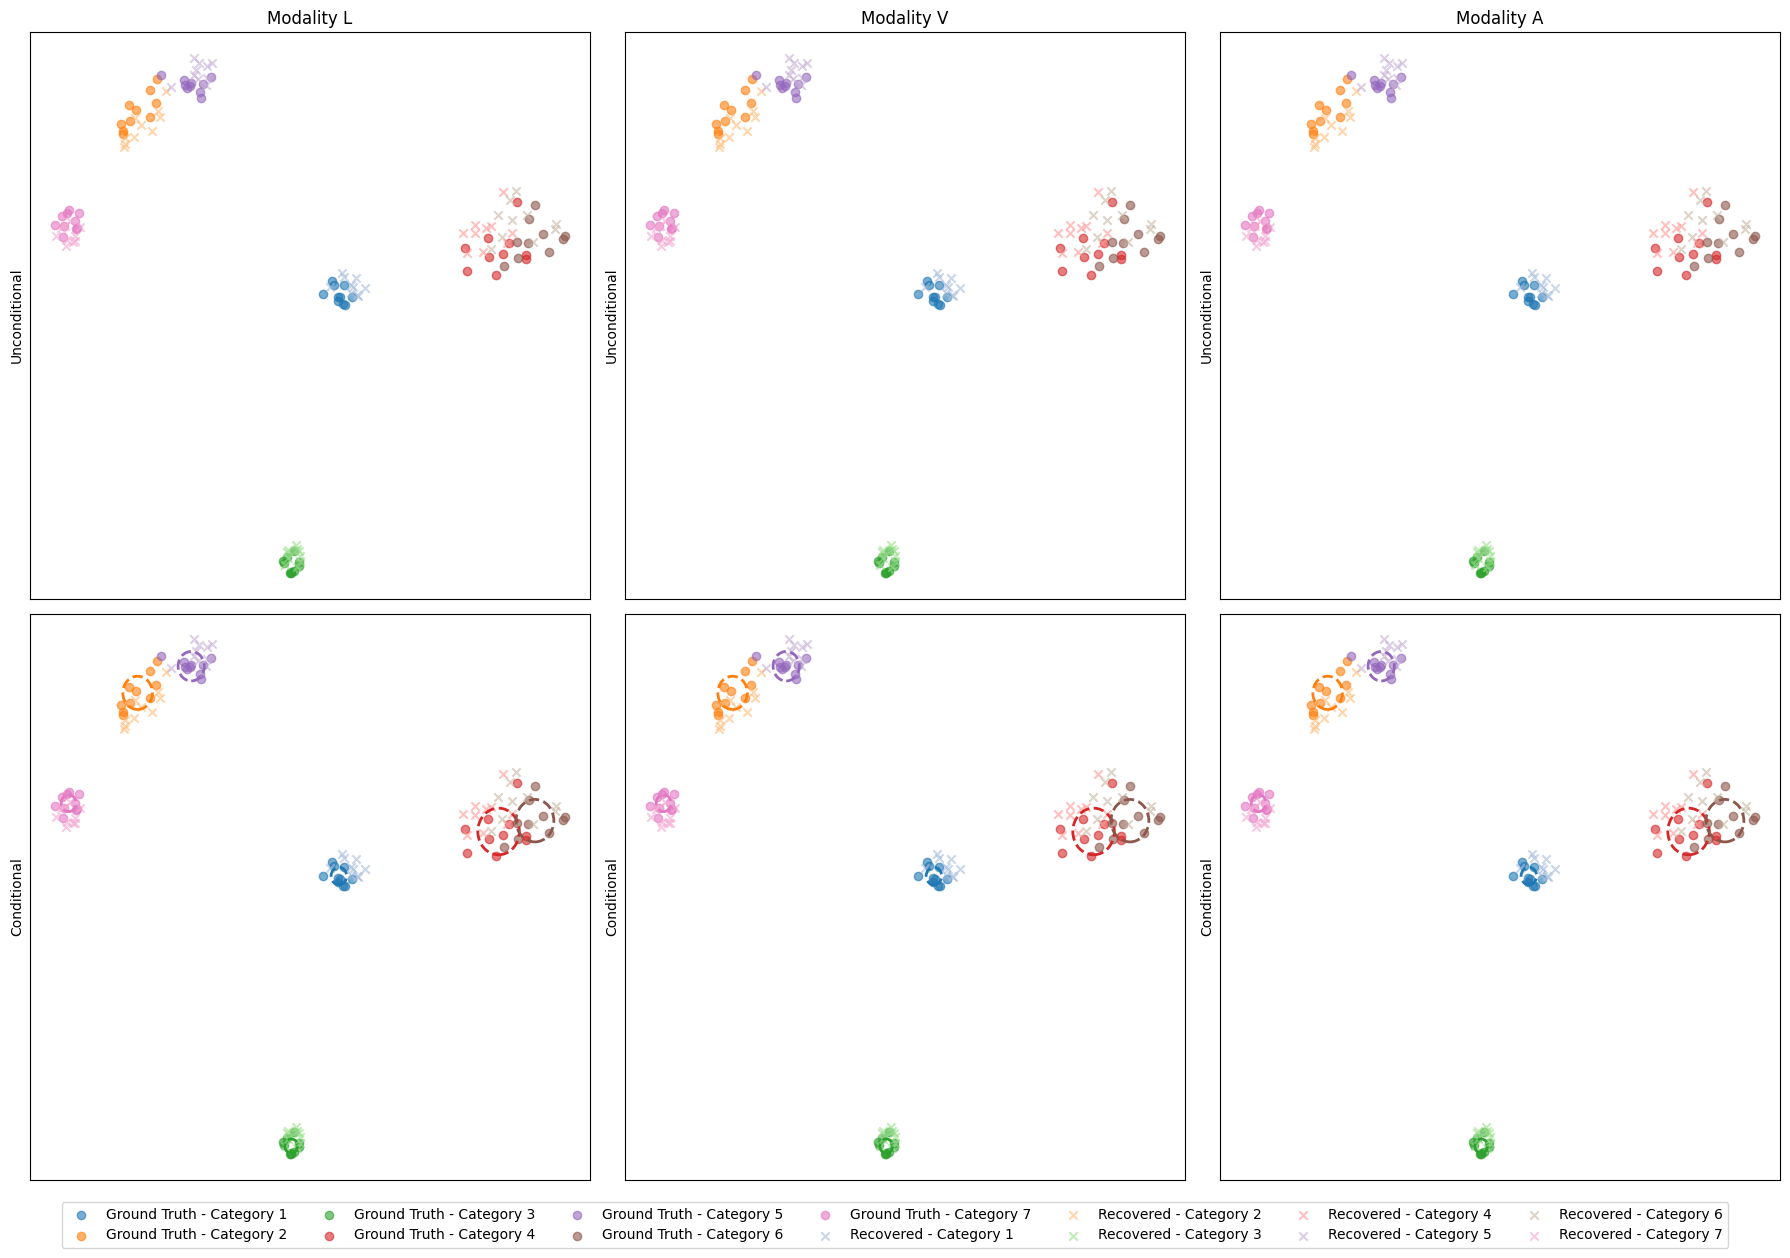

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs
import matplotlib.patches as patches

# Global shape and color mappings
shape_map = ['o', 'x']  # 'o' for ground truth (GT), 'x' for recovered data (Recovered)
category_colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2'
]  # 7 distinct colors for categories
category_light_colors = [
    '#a6bddb', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5', '#c7b6a3', '#f4a6d1'
]  # Lighter shades of the same colors for the recovered data

# Step 1: Random data generation function (for both ground truth and recovered)
def generate_random_data(n_samples=70, n_features=2, n_clusters=7):
    """
    Generate random data for ground truth and recovered.
    The data will be divided into n_clusters categories.
    """
    # Generate data with 7 categories using make_blobs
    X, y = make_blobs(n_samples=n_samples, centers=n_clusters, n_features=n_features, random_state=42)
    return X, y

# Step 2: Apply t-SNE for dimensionality reduction
def apply_tsne(ground_truth_data, recovered_data):
    """
    Apply t-SNE on the combined data (ground_truth and recovered) to reduce it to 2D.
    """
    # Concatenate ground truth and recovered data together
    combined_data = np.vstack([ground_truth_data, recovered_data])
    
    tsne = TSNE(n_components=2, random_state=42, init='pca', n_iter=300)
    reduced_data = tsne.fit_transform(combined_data)
    
    return reduced_data[:len(ground_truth_data)], reduced_data[len(ground_truth_data):]

# Step 3: Visualize each subplot with t-SNE and ground truth/recovered data
def plot_tsne_subplot(ax, ground_truth_data, recovered_data, ground_truth_labels, recovered_labels, title, is_conditional):
    """
    Generate a scatter plot for a single subplot with ground truth and recovered data.
    """
    # Scatter plot for ground truth with dark colors (using 'o' shape)
    for label in np.unique(ground_truth_labels):
        idx = ground_truth_labels == label
        ax.scatter(ground_truth_data[idx, 0], ground_truth_data[idx, 1], 
                   label=f'Ground Truth - Category {label + 1}', color=category_colors[label], alpha=0.6, marker=shape_map[0])

    # Scatter plot for recovered data with light colors (using 'x' shape)
    for label in np.unique(recovered_labels):
        idx = recovered_labels == label
        ax.scatter(recovered_data[idx, 0], recovered_data[idx, 1], 
                   label=f'Recovered - Category {label + 1}', color=category_light_colors[label], alpha=0.6, marker=shape_map[1])

    # If conditional, draw circles around the clusters
    if is_conditional:
        for label in np.unique(ground_truth_labels):
            idx = ground_truth_labels == label
            cluster_center = np.mean(ground_truth_data[idx], axis=0)
            cluster_radius = np.std(ground_truth_data[idx], axis=0).max()  # Radius is the max standard deviation
            circle = patches.Circle(cluster_center, cluster_radius, edgecolor=category_colors[label], facecolor='none', lw=2, linestyle='--')
            ax.add_patch(circle)

    # ax.set_title(title)
    ax.set_xticks([])  # Remove x-axis ticks
    ax.set_yticks([])  # Remove y-axis ticks
    if is_conditional:
        ax.set_ylabel('Conditional')  # Y-axis labels for Conditional
    else:
        ax.set_ylabel('Unconditional')  # Y-axis labels for Unconditional

# Step 4: Generate and visualize data for each subplot
def generate_plots():
    fig, axs = plt.subplots(2, 3, figsize=(18, 12))
    axs = axs.flatten()

    # Define the modalities
    modalities = ['L', 'V', 'A']

    # Generate the data for Unconditional and Conditional Recovering (6 datasets)
    for i, modality in enumerate(modalities):
        # Generate data for ground truth and recovered
        ground_truth_data, ground_truth_labels = generate_random_data(n_samples=70)
        recovered_data, recovered_labels = generate_random_data(n_samples=70)

        # Apply t-SNE to reduce dimensionality and combine the data
        ground_truth_tsne, recovered_tsne = apply_tsne(ground_truth_data + 1 , recovered_data)

        # Unconditional Recovering (First row)
        plot_tsne_subplot(axs[i], ground_truth_tsne, recovered_tsne, ground_truth_labels, recovered_labels, f'Unconditional Recovering ({modality})', False)

        # Conditional Recovering (Second row)
        plot_tsne_subplot(axs[i + 3], ground_truth_tsne, recovered_tsne, ground_truth_labels, recovered_labels, f'Conditional Recovering ({modality})', True)

    # Add combined legend at the bottom
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=7, bbox_to_anchor=(0.5, -0.05), fontsize=10)

    # Adding the modality labels to the top
    for i, ax in enumerate(axs[:3]):
        ax.set_title(f'Modality {modalities[i]}')

    plt.tight_layout()
    plt.show()

# Generate and show the plots
generate_plots()


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs
import matplotlib.patches as patches

def select_samples_per_class(label, samples_per_class=10):
    """
    Selects a specified number of random samples for each class from the labels.

    Parameters:
    - label (numpy array): The array of class labels.
    - samples_per_class (int): The number of samples to select from each class (default is 10).

    Returns:
    - selected_indices (numpy array): The indices of the selected samples across all classes.
    """
    # Use a set to get unique class IDs
    class_ids = set(label)  # Getting unique class IDs using set

    selected_indices = []

    # Loop through each unique class ID
    for class_id in class_ids:
        # Get all the indices for the current class
        class_indices = np.where(label == class_id)[0]
        
        # Randomly select `samples_per_class` indices from the available ones
        if len(class_indices) >= samples_per_class:
            selected_class_indices = np.random.choice(class_indices, samples_per_class, replace=False)
        else:
            # If there are fewer than `samples_per_class`, just take all of them
            selected_class_indices = class_indices
        
        # Append the selected indices for this class
        selected_indices.append(selected_class_indices)

    # Concatenate the selected indices from all classes
    selected_indices = np.concatenate(selected_indices)

    return selected_indices

# Global shape and color mappings
shape_map = ['o', 'x']  # 'o' for ground truth (GT), 'x' for recovered data (Recovered)
category_colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2'
]  # 7 distinct colors for categories
category_light_colors = [
    '#a6bddb', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5', '#c7b6a3', '#f4a6d1'
]  # Lighter shades of the same colors for 